In [28]:
### Import all necessary packages
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

### Task 1: EDA

In [29]:
### load the Dataset
df=pd.read_csv('Pharma_Industry.csv')

In [30]:
### size of the dataset
df.shape

(500, 6)

In [31]:
### data informaton
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [32]:
### statistcal summary
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


In [33]:
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


    Drug Response Classification (0 = No response, 1 = Positive response)

In [34]:
### Check dudplicates
df.duplicated().sum()

np.int64(0)

In [35]:
### Check Missing values
df.isnull().sum()

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

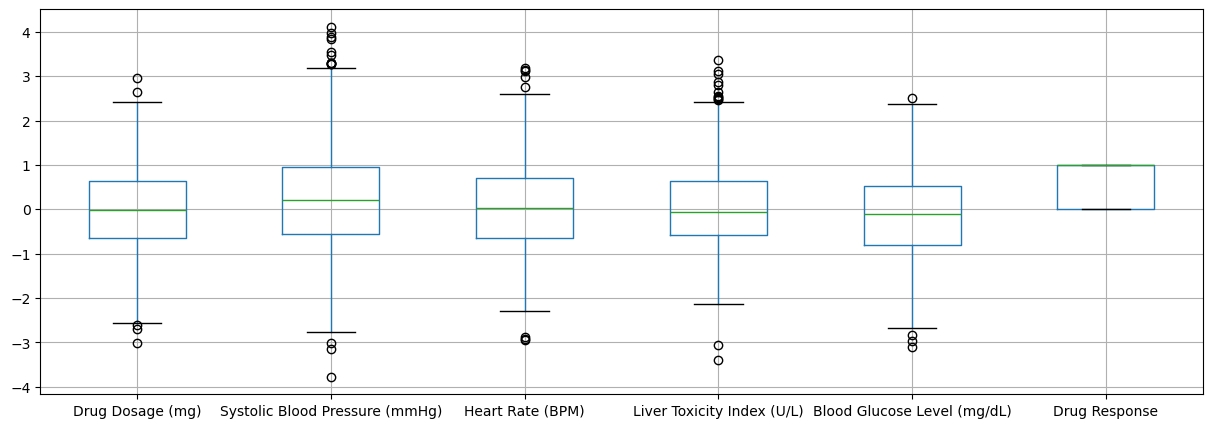

In [36]:
### check outliers
plt.figure(figsize=(15,5))
df.boxplot()
plt.show()

In [37]:
##### Outlier capping
def outlier_capping(df,column):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1
    lower_extreme=Q1-1.5*IQR
    upper_extreme=Q3+1.5*IQR
    df[column]=df[column].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

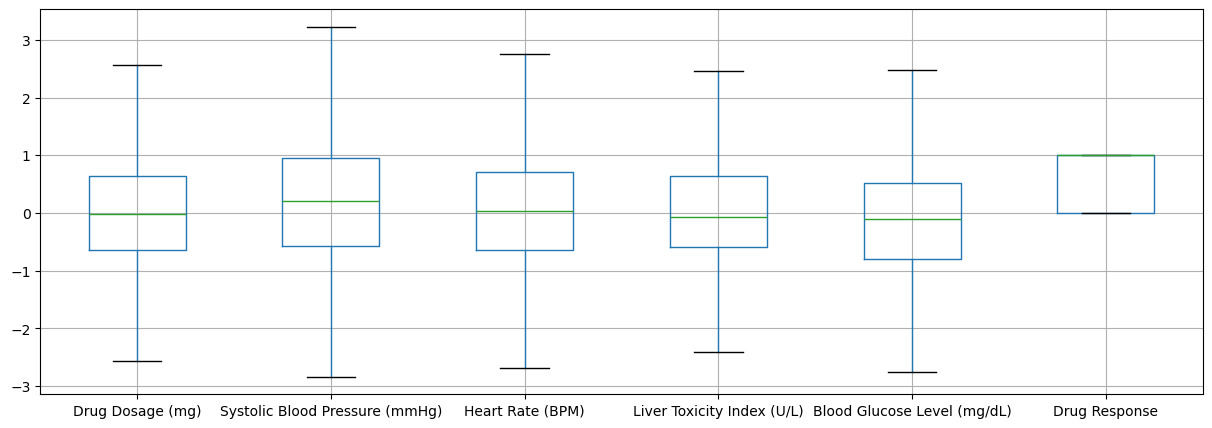

In [38]:
### After capping
### check outliers
plt.figure(figsize=(15,5))
df.boxplot()
plt.show()

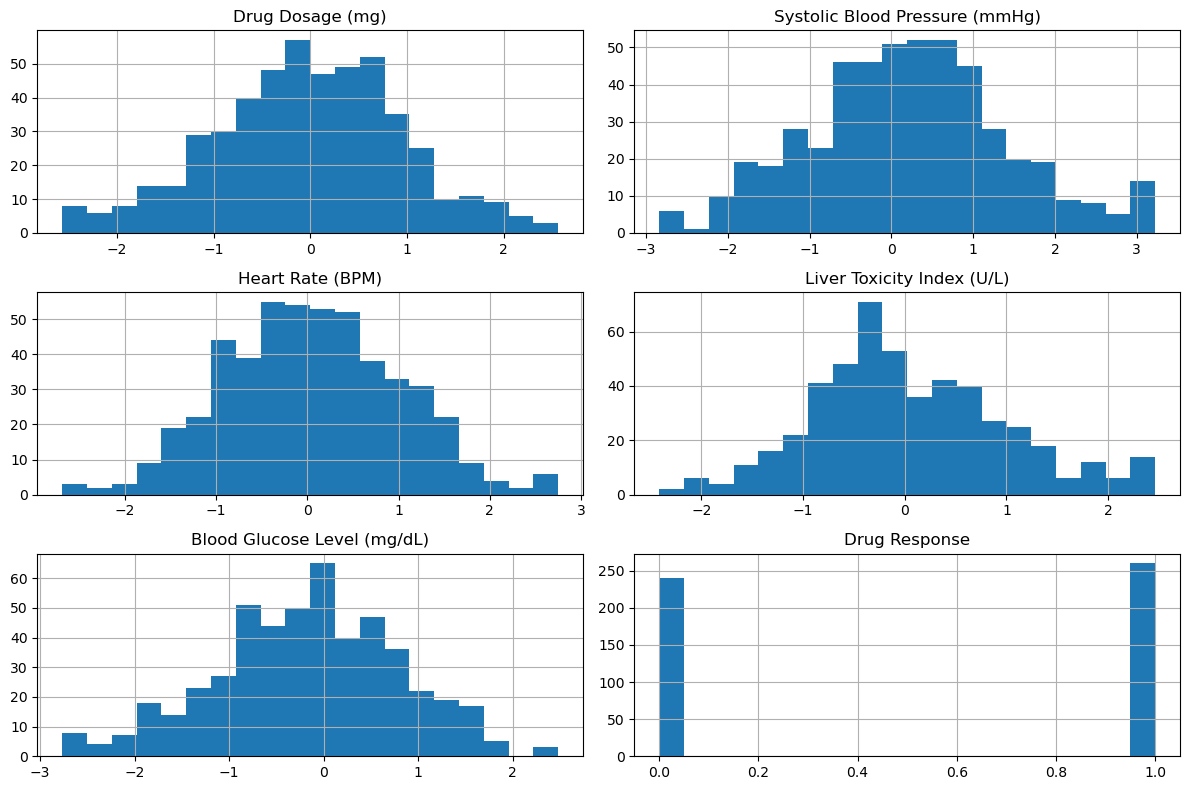

In [39]:
### Histogram plot for features understanding
df.hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()

* Most of the columns follow a bell-shaped distribution.
* The values are mainly concentrated around the center.
* No major skewness is observed in the data.
* The Drug Response classes are almost equally distributed.

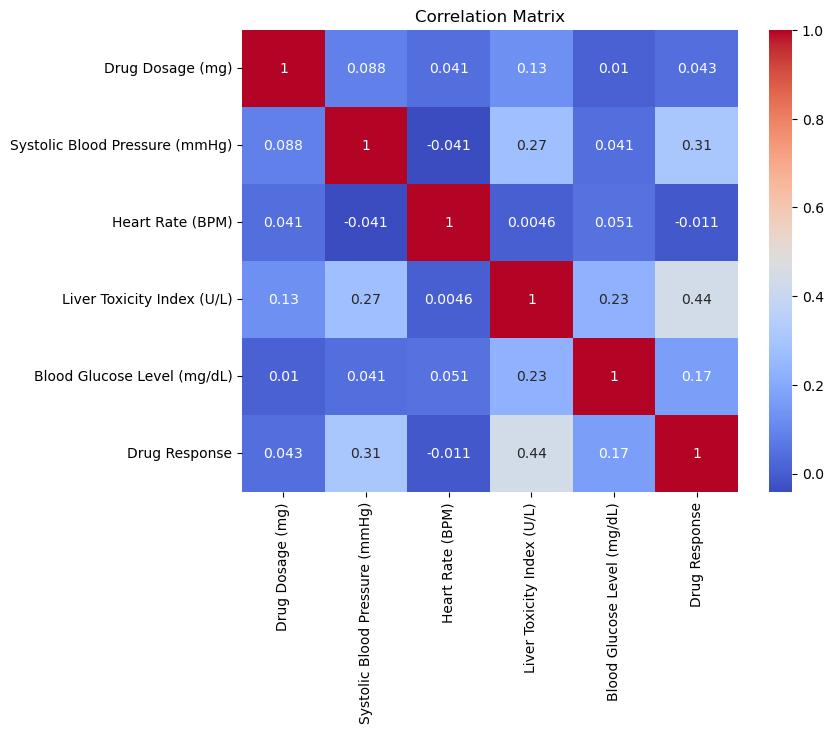

In [40]:
### Corelation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

    The heatmap shows that the features are not highly correlated with each other. Liver Toxicity Index and Systolic Blood Pressure have the strongest relationship with Drug Response, while the remaining features show weak relationships.

### Task 2: Data Preprocessing

In [41]:
target=df[['Drug Response']]
features=df.drop(columns=['Drug Response'])

In [42]:
### train_test_split
x_train,x_test,y_train,y_test=train_test_split(features,target, train_size=0.8,random_state=100,stratify=df['Drug Response'])
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(400, 5)
(100, 5)
(400, 1)
(100, 1)


### Task 3: Data Visualization

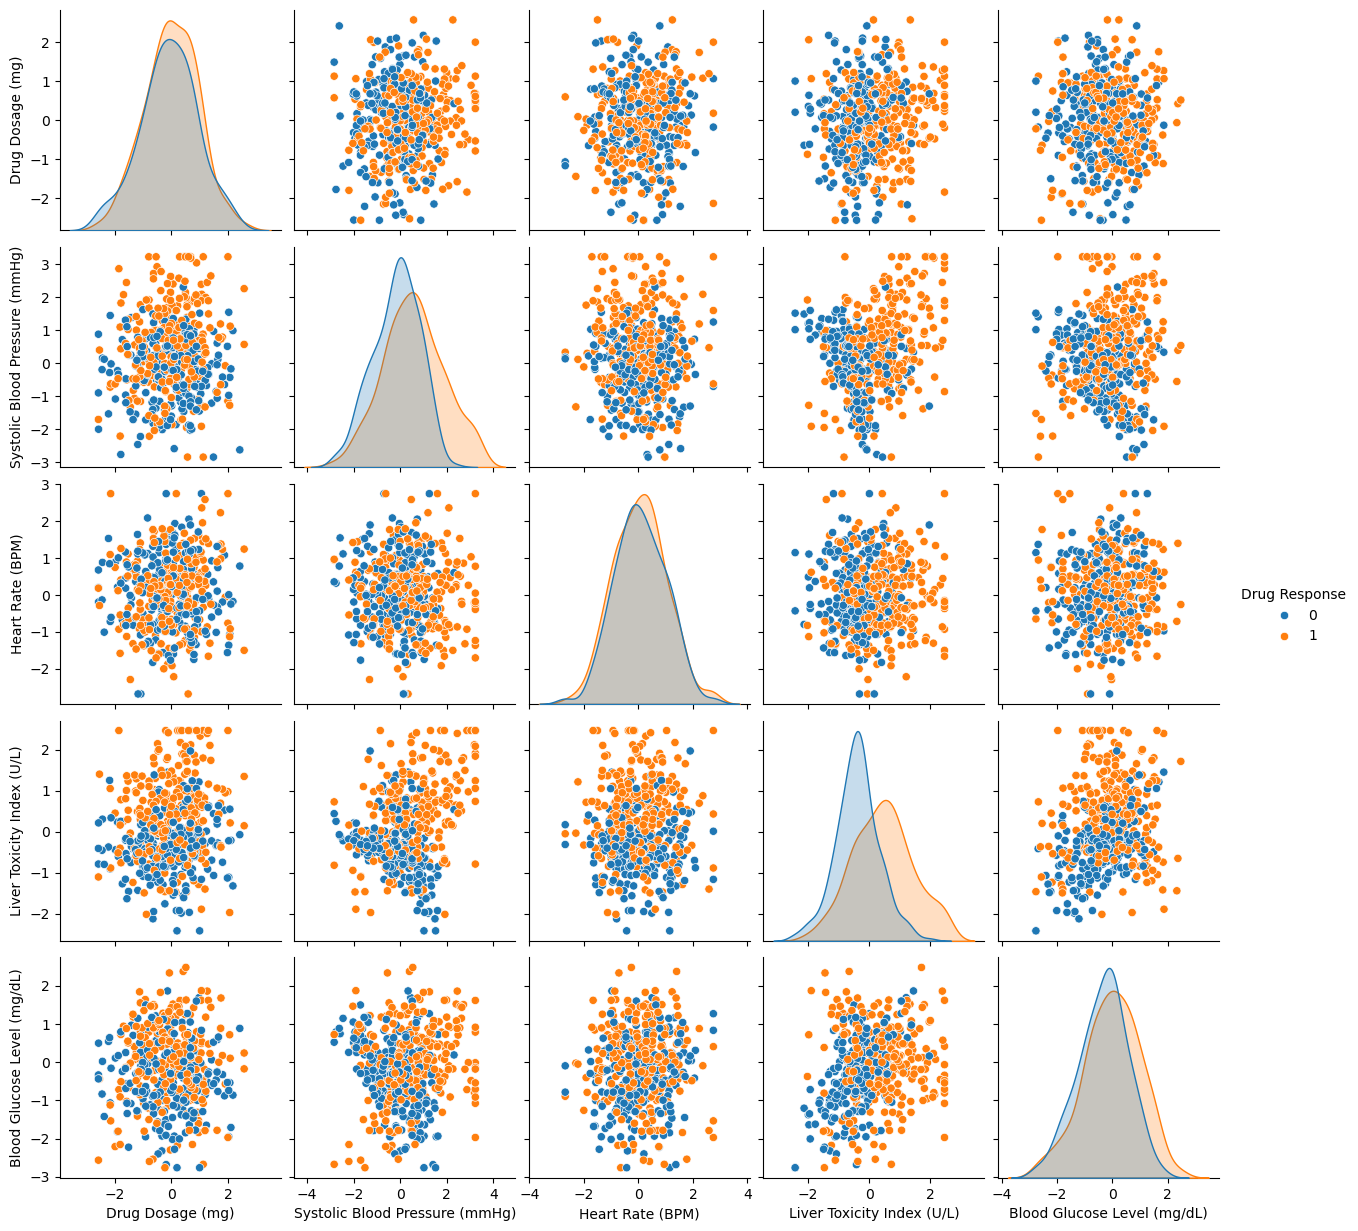

In [43]:
sns.pairplot(df, hue='Drug Response')
plt.show()

* The pair plot shows the relationship between all the features.
* Most of the features have overlapping values for both Drug Response = 0 and Drug Response = 1.
* Liver Toxicity Index and Systolic Blood Pressure show slightly better separation between the two classes compared to the other features.
* Drug Dosage, Heart Rate, and Blood Glucose Level show considerable overlap between the two classes.
* Overall, no single feature clearly separates the two drug response classes, indicating that the SVM model will need to use the combined information from all features for classification.

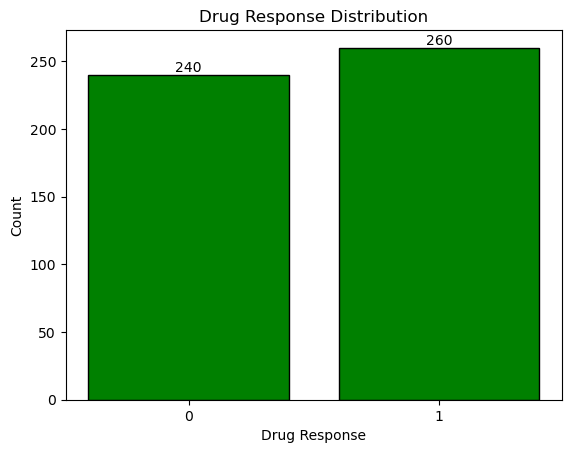

In [44]:
count = df['Drug Response'].value_counts().sort_index()

bars = plt.bar(count.index.astype(str), count.values,
               color='green', edgecolor='black')

plt.bar_label(bars)

plt.xlabel("Drug Response")
plt.ylabel("Count")
plt.title("Drug Response Distribution")

plt.show()

* The dataset contains 240 patients with no response (0) and 260 patients with a positive response (1).
* Both classes have a similar number of records.
* The dataset is nearly balanced, with only a small difference between the two classes.
* This balanced distribution is suitable for training and evaluating the SVM classification model.

### Task 4: SVM Implementation

In [46]:
### Linear Kernel
linear_svc=SVC(kernel='linear')
linear_svc.fit(x_train,y_train)
y_pred=linear_svc.predict(x_test)
accuracy_score(y_test,y_pred)

0.74

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.75      0.73        48
           1       0.76      0.73      0.75        52

    accuracy                           0.74       100
   macro avg       0.74      0.74      0.74       100
weighted avg       0.74      0.74      0.74       100



* The Linear SVM model achieved 74% accuracy on the test dataset.
* The precision, recall, and F1-score are nearly the same for both classes, showing balanced model performance.
* Overall, the model performs reasonably well in predicting drug response.

### Task 5: Visualization of SVM Results

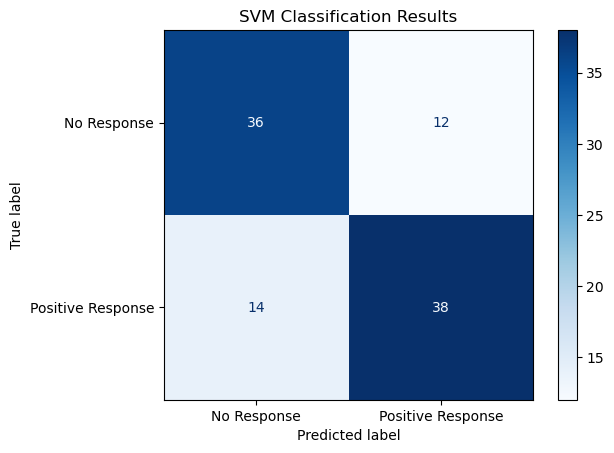

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['No Response', 'Positive Response'])

disp.plot(cmap='Blues')
plt.title("SVM Classification Results")
plt.show()

* The model correctly classified 36 patients with No Response and 38 patients with Positive Response.
* It incorrectly classified 12 No Response patients as Positive Response.
* It incorrectly classified 14 Positive Response patients as No Response.
* Overall, the SVM model correctly classified 74 out of 100 test samples, achieving an accuracy of 74%.
* The confusion matrix indicates that the model performs reasonably well, with a moderate number of misclassifications.

### Task 6: Parameter Tuning and Optimization

In [22]:
from sklearn.model_selection import GridSearchCV

In [23]:
param_grid = {
    'kernel': ['linear', 'poly', 'rbf'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto']
}

In [47]:
grid = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'poly', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of informat

In [25]:
print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Accuracy:", grid.best_score_)

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross Validation Accuracy: 0.7325000000000002


In [49]:
### rbf kernel
rbf_svc = SVC(kernel='rbf')
rbf_svc.fit(x_train, y_train)
y_pred = rbf_svc.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.79
              precision    recall  f1-score   support

           0       0.81      0.73      0.77        48
           1       0.77      0.85      0.81        52

    accuracy                           0.79       100
   macro avg       0.79      0.79      0.79       100
weighted avg       0.79      0.79      0.79       100



* The RBF SVM model achieved an accuracy of 79% on the test dataset.
* The model correctly classified 79% of the test samples.
* The precision, recall, and F1-score are balanced for both classes, indicating good classification performance.
* The model predicted the Positive Response (Class 1) slightly better than the No Response (Class 0), with a higher recall of 85%.
* Overall, the RBF kernel performed better than the Linear kernel, improving the accuracy from 74% to 79%.

### Task 7: Comparison and Analysis

In [50]:
### Poly kernel
poly_svc = SVC(kernel='poly')
poly_svc.fit(x_train, y_train)
y_pred =poly_svc.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.76
              precision    recall  f1-score   support

           0       0.72      0.81      0.76        48
           1       0.80      0.71      0.76        52

    accuracy                           0.76       100
   macro avg       0.76      0.76      0.76       100
weighted avg       0.76      0.76      0.76       100



* The Polynomial SVM model achieved an accuracy of 76% on the test dataset.
* The model correctly classified 76% of the test samples.
* The precision, recall, and F1-score are balanced, indicating good classification performance.
* The model identified No Response (Class 0) slightly better in terms of recall (81%), while Positive Response (Class 1) had a precision of 80%.
* Overall, the Polynomial kernel performed better than the Linear kernel (74%) but slightly lower than the RBF kernel (79%).

 ##### 1.	Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function).

    | Kernel     | Accuracy |
    | ---------- | -------: |
    | Linear     |      74% |
    | Polynomial |      76% |
    | RBF        |      79% |


* The Linear kernel achieved an accuracy of 74%.
* The Polynomial kernel improved the accuracy to 76%.
* The RBF kernel achieved the highest accuracy of 79%.
* Among the three kernels, the RBF kernel performed the best for this dataset.
* Therefore, the RBF kernel is the most suitable choice for predicting drug response because it provides the highest classification accuracy.

##### 2. Analyze SVM strengths and weaknesses for the dataset based on EDA and visualization results.

**Strengths**
* The class distribution plot shows that the dataset is nearly balanced, which helps the SVM model learn both classes effectively.
* The SVM model performed well in classifying the drug response data.
* The RBF kernel achieved the highest accuracy (79%), indicating better performance than the Linear and Polynomial kernels.
* The model achieved balanced precision, recall, and F1-score for both classes.
  
**Weaknesses**
* The pair plot shows overlap between the two classes, making classification more challenging.
* No single feature clearly separates the drug response classes.
* Some samples were misclassified, so the model did not achieve perfect accuracy.
8 The performance of SVM depends on selecting the appropriate kernel and hyperparameters.

##### 3. Discuss practical implications of SVM in real-world classification tasks.

* SVM can help predict whether a patient will respond to a drug before treatment.
* It can assist pharmaceutical companies in identifying effective drugs during clinical trials.
* Early prediction of drug response can reduce the time and cost of drug development.
* SVM supports personalized medicine by helping doctors choose the most suitable treatment for each patient.
* It can improve decision-making and reduce the chances of prescribing ineffective drugs.



#### Conclusion

The SVM model successfully classified drug response using patient health data. Among the three kernels tested, the RBF kernel achieved the highest accuracy of 79%, making it the best-performing model for this dataset. SVM can be effectively used in healthcare to support drug response prediction and personalized treatment decisions.